# Cosine Similarity & Vector Search — Complete Project Notebook

**Goal:** Build every piece of a similarity engine from scratch, then verify it matches `scikit-learn`.  
**Stack:** `numpy` · `scikit-learn` · `sentence-transformers` · `matplotlib` · `seaborn`

---
## Table of Contents
1. [Setup & Imports](#1)
2. [The Math From Scratch](#2) — dot product, magnitude, cosine
3. [Verify Against sklearn](#3) — prove our math matches the library
4. [Real Embeddings with sentence-transformers](#4)
5. [Feature 1 — Similarity Matrix & Heatmap](#5)
6. [Feature 2 — Outlier Detector](#6)
7. [Feature 3 — Threshold Retrieval](#7)
8. [Bonus: L2 vs Cosine Showdown](#8)
9. [Bonus: Build a Mini RAG Retriever](#9)
10. [Challenge Tasks](#10)

---
## 1. Setup & Imports <a id='1'></a>

Install everything you need. Run this cell first — it takes ~1 minute on first run.

In [1]:
# Install dependencies (run once)
!pip install numpy scikit-learn sentence-transformers matplotlib seaborn --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
from sklearn.metrics.pairwise import euclidean_distances
from sentence_transformers import SentenceTransformer

np.random.seed(42)
print("All imports successful!")
print(f"NumPy version: {np.__version__}")

All imports successful!
NumPy version: 2.0.2


---
## 2. The Math From Scratch <a id='2'></a>

Before touching any library, implement every formula manually.  
This is the foundation everything else rests on.

### The three formulas:

$$\text{dot}(A, B) = \sum_{i=1}^{n} a_i \cdot b_i$$

$$\|A\| = \sqrt{\sum_{i=1}^{n} a_i^2}$$

$$\cos(\theta) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

In [3]:
def dot_product(a: np.ndarray, b: np.ndarray) -> float:
    """Sum of element-wise products. No numpy.dot allowed here."""
    return float(np.sum(a * b))

def magnitude(v: np.ndarray) -> float:
    """Euclidean length of a vector."""
    return float(np.sqrt(np.sum(v ** 2)))

def cosine_similarity_scratch(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity: measures angle, ignores magnitude."""
    mag_a = magnitude(a)
    mag_b = magnitude(b)
    if mag_a == 0 or mag_b == 0:
        return 0.0
    return dot_product(a, b) / (mag_a * mag_b)

def cosine_matrix_scratch(embeddings: np.ndarray) -> np.ndarray:
    """Build the full N x N similarity matrix from scratch."""
    n = len(embeddings)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            matrix[i][j] = cosine_similarity_scratch(embeddings[i], embeddings[j])
    return matrix

print("Functions defined. Running sanity checks...")

Functions defined. Running sanity checks...


In [4]:
# Four cases every AI engineer must know
A = np.array([3.0, 4.0])
B = np.array([1.0, 2.0])

cases = [
    (A, B,                      "Normal case",         None),
    (A, A,                      "Identical vectors",    1.0),
    (A, A * 5,                  "Same dir, 5x scale",  1.0),
    (A, -A,                     "Opposite direction",  -1.0),
    (A, np.array([4.0, -3.0]),  "Perpendicular",        0.0),
]

print(f"{'Case':<25} {'Dot':>8} {'|A|':>6} {'|B|':>6} {'Cosine':>8} {'Expected':>10} {'Pass?':>6}")
print("-" * 75)
for a, b, label, expected in cases:
    d   = dot_product(a, b)
    ma  = magnitude(a)
    mb  = magnitude(b)
    cos = cosine_similarity_scratch(a, b)
    exp_str = f"{expected:.3f}" if expected is not None else "  —"
    passed  = "✓" if (expected is None or abs(cos - expected) < 1e-9) else "✗"
    print(f"{label:<25} {d:>8.3f} {ma:>6.3f} {mb:>6.3f} {cos:>8.4f} {exp_str:>10} {passed:>6}")

Case                           Dot    |A|    |B|   Cosine   Expected  Pass?
---------------------------------------------------------------------------
Normal case                 11.000  5.000  2.236   0.9839          —      ✓
Identical vectors           25.000  5.000  5.000   1.0000      1.000      ✓
Same dir, 5x scale         125.000  5.000 25.000   1.0000      1.000      ✓
Opposite direction         -25.000  5.000  5.000  -1.0000     -1.000      ✓
Perpendicular                0.000  5.000  5.000   0.0000      0.000      ✓


### Why does scaling not change cosine similarity?

If `B' = k·B` for any scalar `k > 0`:

$$\cos(A, kB) = \frac{A \cdot kB}{\|A\| \cdot \|kB\|} = \frac{k(A \cdot B)}{\|A\| \cdot k\|B\|} = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

The `k` cancels top and bottom. **This is why cosine is used in RAG** — a long document about the same topic as a short one should have equal retrieval priority.

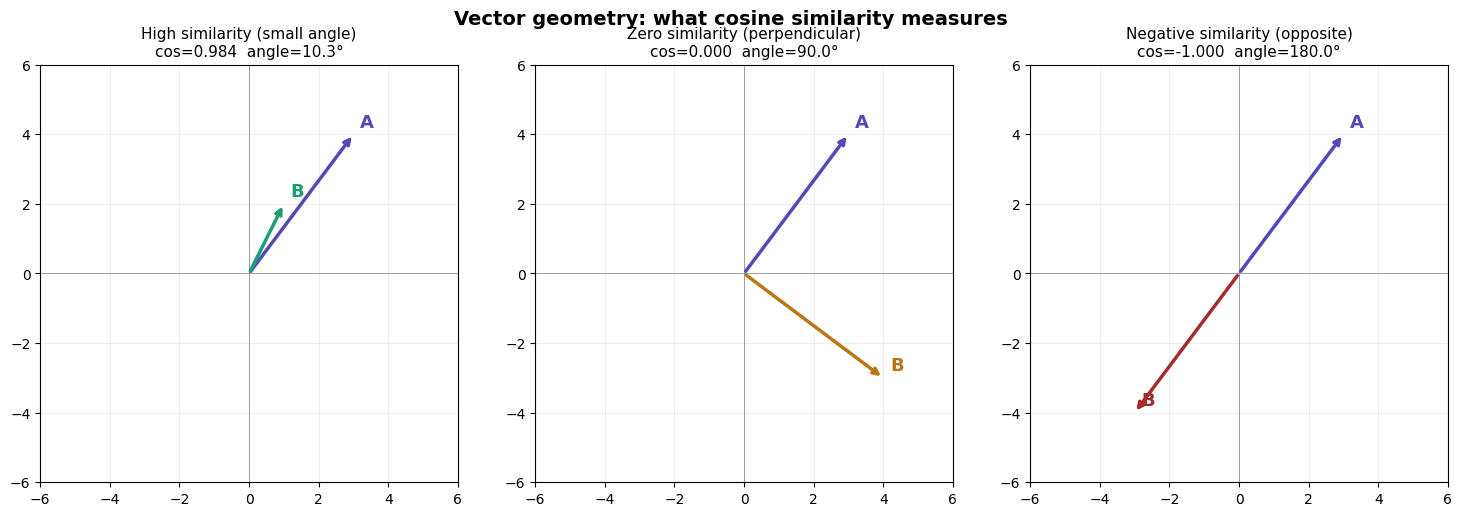

Saved: 01_vector_geometry.png


In [5]:
# Visualise: two vectors in 2D space
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Vector geometry: what cosine similarity measures", fontsize=14, fontweight='bold')

scenarios = [
    (np.array([3, 4]), np.array([1, 2]),   "High similarity (small angle)",  "#1D9E75"),
    (np.array([3, 4]), np.array([4, -3]),  "Zero similarity (perpendicular)", "#BA7517"),
    (np.array([3, 4]), np.array([-3, -4]), "Negative similarity (opposite)",  "#A32D2D"),
]

for ax, (a, b, title, color) in zip(axes, scenarios):
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.grid(True, alpha=0.2)
    ax.annotate('', xy=a, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#534AB7', lw=2.5))
    ax.annotate('', xy=b, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(a[0]+0.2, a[1]+0.2, 'A', fontsize=13, color='#534AB7', fontweight='bold')
    ax.text(b[0]+0.2, b[1]+0.2, 'B', fontsize=13, color=color, fontweight='bold')
    cos = cosine_similarity_scratch(a.astype(float), b.astype(float))
    angle = np.degrees(np.arccos(np.clip(cos, -1, 1)))
    ax.set_title(f"{title}\ncos={cos:.3f}  angle={angle:.1f}°", fontsize=11)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('01_vector_geometry.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_vector_geometry.png")

---
## 3. Verify Against sklearn <a id='3'></a>

Prove our scratch implementation produces identical results to the battle-tested library.

In [7]:
fake_embeddings = np.random.randn(8, 128)

our_matrix     = cosine_matrix_scratch(fake_embeddings)
sklearn_matrix = sklearn_cosine(fake_embeddings)

max_diff = np.max(np.abs(our_matrix - sklearn_matrix))
print(f"Max absolute difference between our impl and sklearn: {max_diff:.2e}")
print(f"All values within 1e-10: {max_diff < 1e-10}")

print("\nsklearn internal vectorized form:")
print("  norms      = np.linalg.norm(E, axis=1, keepdims=True)")
print("  normalized = E / norms")
print("  matrix     = normalized @ normalized.T")

norms      = np.linalg.norm(fake_embeddings, axis=1, keepdims=True)
normalized = fake_embeddings / norms
fast_matrix = normalized @ normalized.T
print(f"\nVectorized vs sklearn max diff: {np.max(np.abs(fast_matrix - sklearn_matrix)):.2e}")

Max absolute difference between our impl and sklearn: 6.66e-16
All values within 1e-10: True

sklearn internal vectorized form:
  norms      = np.linalg.norm(E, axis=1, keepdims=True)
  normalized = E / norms
  matrix     = normalized @ normalized.T

Vectorized vs sklearn max diff: 8.88e-16


---
## 4. Real Embeddings with sentence-transformers <a id='4'></a>

`all-MiniLM-L6-v2` is a 22M parameter model producing 384-dimensional vectors.  
It's fast, free, runs locally, and good enough for most RAG prototypes.

In [8]:
print("Loading model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded. Output dimensions: {model.get_sentence_embedding_dimension()}")

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded. Output dimensions: 384


/tmp/ipykernel_8838/2015376762.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded. Output dimensions: {model.get_sentence_embedding_dimension()}")


In [9]:
# Two clear clusters + one deliberate outlier
documents = [
    # Cluster A: animals / outdoors
    "The golden retriever ran across the park.",
    "A puppy played in the green grass.",
    "Dogs love to fetch balls outdoors.",
    "The labrador swam in the lake happily.",
    # Cluster B: data science / ML
    "Data science involves statistics and coding.",
    "Machine learning models require clean data.",
    "Neural networks learn from large datasets.",
    "Feature engineering improves model accuracy.",
    # Outlier: unrelated to both
    "The stock market closed higher on Friday.",
]

labels = [d[:30] + ("..." if len(d) > 30 else "") for d in documents]

print(f"Embedding {len(documents)} documents...")
embeddings = model.encode(documents, show_progress_bar=True)
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Each document -> {embeddings.shape[1]}-dimensional vector")

Embedding 9 documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embeddings shape: (9, 384)
Each document -> 384-dimensional vector


---
## 5. Feature 1 — Similarity Matrix & Heatmap <a id='5'></a>

Compute every document's similarity to every other document.  
The matrix is symmetric: `matrix[i][j] == matrix[j][i]`.  
The diagonal is always 1.0: every document is identical to itself.

In [10]:
sim_matrix = sklearn_cosine(embeddings)

print("Similarity matrix (first 3x3 corner):")
print(np.round(sim_matrix[:3, :3], 3))
print(f"\nMatrix shape: {sim_matrix.shape}")
print(f"Diagonal values (should all be 1.0): {np.round(np.diag(sim_matrix), 4)}")
print(f"Is symmetric: {np.allclose(sim_matrix, sim_matrix.T)}")

Similarity matrix (first 3x3 corner):
[[1.    0.302 0.359]
 [0.302 1.    0.331]
 [0.359 0.331 1.   ]]

Matrix shape: (9, 9)
Diagonal values (should all be 1.0): [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Is symmetric: True


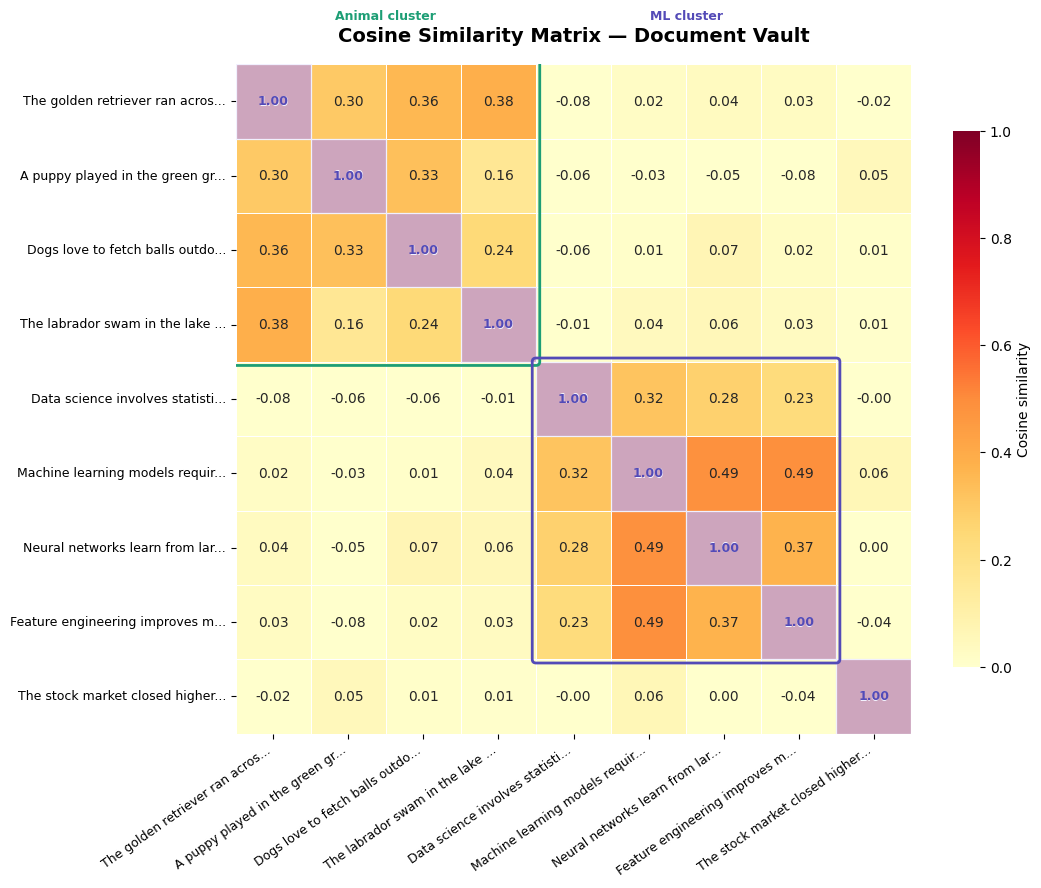

Saved: 02_heatmap.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    sim_matrix,
    annot=True, fmt=".2f",
    cmap="YlOrRd", vmin=0, vmax=1,
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={"label": "Cosine similarity", "shrink": 0.8}
)

# Highlight diagonal
for i in range(len(documents)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True,
                                color='#EEEDFE', zorder=3, alpha=0.7))
    ax.text(i+0.5, i+0.5, '1.00', ha='center', va='center',
            fontsize=9, color='#534AB7', fontweight='bold', zorder=4)

ax.set_title("Cosine Similarity Matrix — Document Vault",
             fontsize=14, fontweight='bold', pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# Cluster boxes
ax.add_patch(mpatches.FancyBboxPatch((0,0), 4, 4, boxstyle="round,pad=0.05",
             linewidth=2, edgecolor='#1D9E75', facecolor='none', zorder=5))
ax.text(2, -0.6, 'Animal cluster', ha='center', color='#1D9E75',
        fontsize=9, fontweight='bold')

ax.add_patch(mpatches.FancyBboxPatch((4,4), 4, 4, boxstyle="round,pad=0.05",
             linewidth=2, edgecolor='#534AB7', facecolor='none', zorder=5))
ax.text(6, -0.6, 'ML cluster', ha='center', color='#534AB7',
        fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_heatmap.png")

In [12]:
# Read the matrix like an AI engineer
pairs = []
for i in range(len(documents)):
    for j in range(i+1, len(documents)):
        pairs.append((sim_matrix[i][j], i, j))

pairs.sort(reverse=True)

print("Top 5 most similar pairs:")
for score, i, j in pairs[:5]:
    print(f"  {score:.3f}  [{i}] {documents[i][:40]}")
    print(f"         [{j}] {documents[j][:40]}")
    print()

print("Bottom 5 (most dissimilar):")
for score, i, j in pairs[-5:]:
    print(f"  {score:.3f}  [{i}] {documents[i][:40]}")
    print(f"         [{j}] {documents[j][:40]}")
    print()

Top 5 most similar pairs:
  0.490  [5] Machine learning models require clean da
         [7] Feature engineering improves model accur

  0.488  [5] Machine learning models require clean da
         [6] Neural networks learn from large dataset

  0.384  [0] The golden retriever ran across the park
         [3] The labrador swam in the lake happily.

  0.373  [6] Neural networks learn from large dataset
         [7] Feature engineering improves model accur

  0.359  [0] The golden retriever ran across the park
         [2] Dogs love to fetch balls outdoors.

Bottom 5 (most dissimilar):
  -0.046  [1] A puppy played in the green grass.
         [6] Neural networks learn from large dataset

  -0.055  [2] Dogs love to fetch balls outdoors.
         [4] Data science involves statistics and cod

  -0.059  [1] A puppy played in the green grass.
         [4] Data science involves statistics and cod

  -0.078  [0] The golden retriever ran across the park
         [4] Data science involves statist

---
## 6. Feature 2 — Outlier Detector <a id='6'></a>

The outlier is the document least similar to the rest of the corpus on average.  
**Why this matters:** Outliers are often table-of-contents pages, disclaimers, or off-topic docs.  
Surface them at ingestion time to prevent bad retrievals later.

In [13]:
n = len(documents)
avg_similarities = []
for i in range(n):
    others = [sim_matrix[i][j] for j in range(n) if j != i]
    avg_similarities.append(np.mean(others))

outlier_idx = int(np.argmin(avg_similarities))

print("Average similarity to corpus (sorted ascending):")
ranked = sorted(enumerate(avg_similarities), key=lambda x: x[1])
for rank, (idx, score) in enumerate(ranked):
    marker = "  <-- OUTLIER" if idx == outlier_idx else ""
    print(f"  {rank+1}. [{score:.3f}]  {documents[idx][:55]}{marker}")

print(f"\nOutlier: \"{documents[outlier_idx]}\"")
print(f"Avg similarity: {avg_similarities[outlier_idx]:.3f}")

Average similarity to corpus (sorted ascending):
  1. [0.006]  The stock market closed higher on Friday.  <-- OUTLIER
  2. [0.078]  Data science involves statistics and coding.
  3. [0.079]  A puppy played in the green grass.
  4. [0.115]  The labrador swam in the lake happily.
  5. [0.124]  Dogs love to fetch balls outdoors.
  6. [0.129]  The golden retriever ran across the park.
  7. [0.132]  Feature engineering improves model accuracy.
  8. [0.157]  Neural networks learn from large datasets.
  9. [0.175]  Machine learning models require clean data.

Outlier: "The stock market closed higher on Friday."
Avg similarity: 0.006


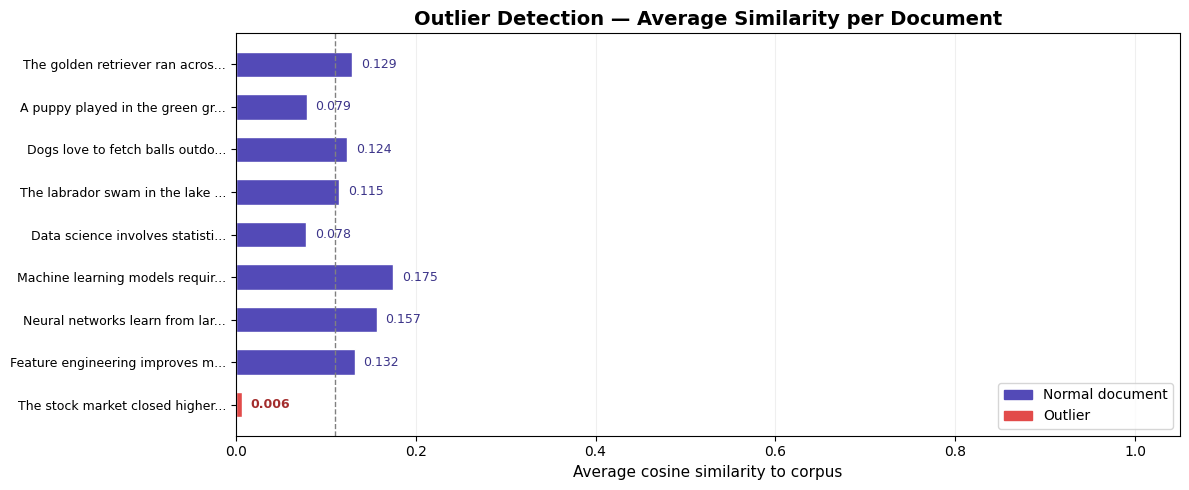

Saved: 03_outlier_detection.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#E24B4A' if i == outlier_idx else '#534AB7' for i in range(n)]
bars = ax.barh(range(n), avg_similarities, color=colors, height=0.6, edgecolor='white')

ax.set_yticks(range(n))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Average cosine similarity to corpus", fontsize=11)
ax.set_title("Outlier Detection — Average Similarity per Document",
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.axvline(x=np.mean(avg_similarities), color='gray', linestyle='--', linewidth=1,
           label=f'Corpus avg: {np.mean(avg_similarities):.3f}')

for i, (bar, score) in enumerate(zip(bars, avg_similarities)):
    ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
            f"{score:.3f}", va='center', fontsize=9,
            color='#A32D2D' if i == outlier_idx else '#3C3489',
            fontweight='bold' if i == outlier_idx else 'normal')

legend_patches = [
    mpatches.Patch(color='#534AB7', label='Normal document'),
    mpatches.Patch(color='#E24B4A', label='Outlier'),
]
ax.legend(handles=legend_patches, loc='lower right')
ax.grid(axis='x', alpha=0.2)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('03_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_outlier_detection.png")

In [15]:
def detect_outliers(documents, embeddings, threshold_std=1.0):
    """
    Detect outliers using z-score on average similarities.
    Returns docs sorted by z_score (most outlier-like first).
    """
    matrix = sklearn_cosine(embeddings)
    n = len(documents)
    avgs = [(matrix[i].sum() - 1) / (n - 1) for i in range(n)]
    mean, std = np.mean(avgs), np.std(avgs)

    results = []
    for i, (doc, avg) in enumerate(zip(documents, avgs)):
        z = (avg - mean) / std if std > 0 else 0
        results.append({
            'idx': i, 'document': doc,
            'avg_similarity': round(avg, 4),
            'z_score': round(z, 3),
            'is_outlier': z < -threshold_std
        })
    return sorted(results, key=lambda x: x['z_score'])

outliers = detect_outliers(documents, embeddings)
print("Outlier analysis (z-score method):")
for r in outliers:
    flag = "  <-- OUTLIER" if r['is_outlier'] else ""
    print(f"  z={r['z_score']:>6.2f}  sim={r['avg_similarity']:.3f}  {r['document'][:50]}{flag}")

Outlier analysis (z-score method):
  z= -2.20  sim=0.006  The stock market closed higher on Friday.  <-- OUTLIER
  z= -0.68  sim=0.078  Data science involves statistics and coding.
  z= -0.67  sim=0.079  A puppy played in the green grass.
  z=  0.09  sim=0.115  The labrador swam in the lake happily.
  z=  0.28  sim=0.124  Dogs love to fetch balls outdoors.
  z=  0.39  sim=0.129  The golden retriever ran across the park.
  z=  0.46  sim=0.132  Feature engineering improves model accuracy.
  z=  0.97  sim=0.157  Neural networks learn from large datasets.
  z=  1.36  sim=0.175  Machine learning models require clean data.


---
## 7. Feature 3 — Threshold Retrieval <a id='7'></a>

Given a query, find only documents exceeding a minimum similarity score.  
This is the exact mechanism inside every RAG retriever.

In [16]:
def retrieve(query, documents, embeddings, model, threshold=0.0, top_k=None):
    """
    Retrieve documents above a similarity threshold, ranked by score.

    Args:
        threshold: 0.0 = return all, 0.75 = strict filtering
        top_k:     cap results after threshold filter
    """
    query_vec = model.encode([query])
    scores = sklearn_cosine(query_vec, embeddings)[0]

    results = [
        {'rank': 0, 'score': float(scores[i]), 'document': documents[i], 'idx': i}
        for i in range(len(documents))
        if scores[i] >= threshold
    ]
    results.sort(key=lambda x: x['score'], reverse=True)
    if top_k:
        results = results[:top_k]
    for rank, r in enumerate(results, 1):
        r['rank'] = rank
    return results


# Test several queries
test_queries = [
    ("dog playing outside",       0.30),
    ("artificial intelligence",   0.30),
    ("financial markets trading", 0.20),
]

for query, threshold in test_queries:
    results = retrieve(query, documents, embeddings, model, threshold=threshold)
    print(f"\nQuery: '{query}'  (threshold={threshold})")
    if not results:
        print("  No results above threshold.")
    for r in results:
        bar = 'x' * int(r['score'] * 30)
        print(f"  #{r['rank']} [{r['score']:.3f}] {bar}")
        print(f"         {r['document']}")


Query: 'dog playing outside'  (threshold=0.3)
  #1 [0.650] xxxxxxxxxxxxxxxxxxx
         A puppy played in the green grass.
  #2 [0.538] xxxxxxxxxxxxxxxx
         Dogs love to fetch balls outdoors.
  #3 [0.432] xxxxxxxxxxxx
         The golden retriever ran across the park.

Query: 'artificial intelligence'  (threshold=0.3)
  #1 [0.370] xxxxxxxxxxx
         Neural networks learn from large datasets.
  #2 [0.301] xxxxxxxxx
         Machine learning models require clean data.

Query: 'financial markets trading'  (threshold=0.2)
  #1 [0.361] xxxxxxxxxx
         The stock market closed higher on Friday.


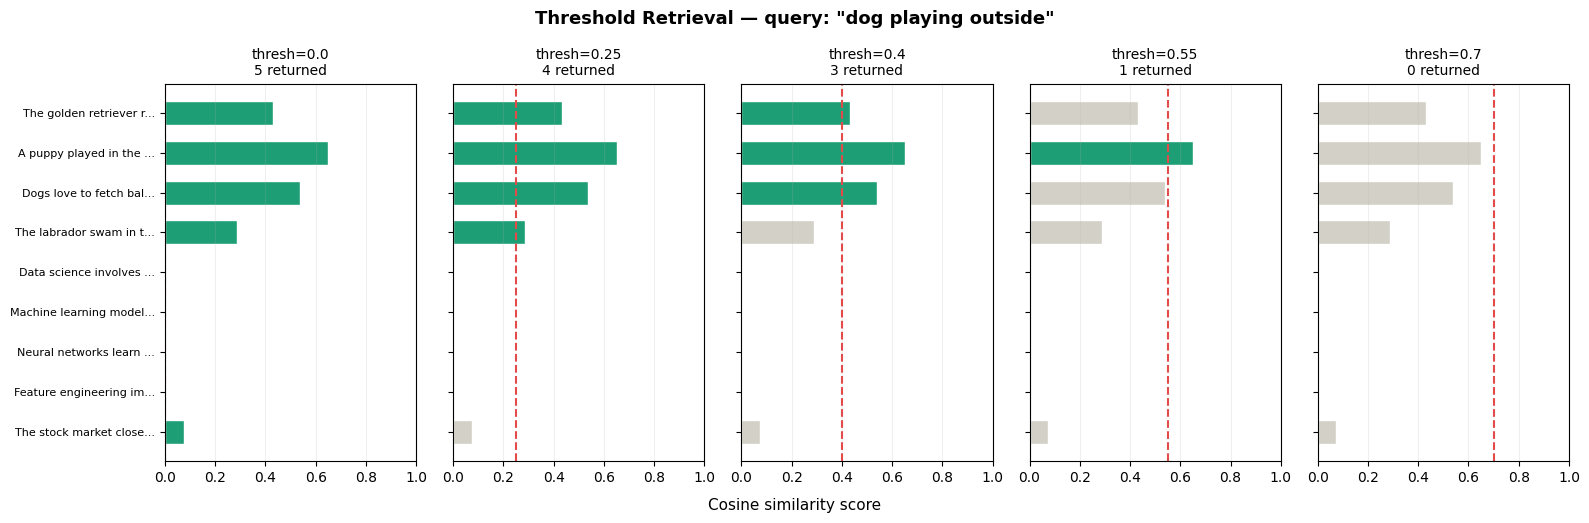

Saved: 04_threshold_retrieval.png


In [17]:
# Visualise: how threshold changes what gets returned
query = "dog playing outside"
q_vec = model.encode([query])
all_scores = sklearn_cosine(q_vec, embeddings)[0]

thresholds = [0.0, 0.25, 0.40, 0.55, 0.70]
fig, axes = plt.subplots(1, len(thresholds), figsize=(16, 5), sharey=True)
fig.suptitle(f'Threshold Retrieval — query: "{query}"', fontsize=13, fontweight='bold')

for ax, thresh in zip(axes, thresholds):
    colors = ['#1D9E75' if s >= thresh else '#D3D1C7' for s in all_scores]
    ax.barh(range(len(documents)), all_scores, color=colors, height=0.6, edgecolor='white')
    ax.axvline(x=thresh, color='#E24B4A', linestyle='--', linewidth=1.5)
    ax.set_xlim(0, 1)
    ax.set_title(f"thresh={thresh}\n{sum(s >= thresh for s in all_scores)} returned", fontsize=10)
    ax.set_yticks(range(len(documents)))
    if ax == axes[0]:
        ax.set_yticklabels([d[:22] + '...' if len(d) > 22 else d for d in documents], fontsize=8)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.2)

fig.text(0.5, -0.02, 'Cosine similarity score', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('04_threshold_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_threshold_retrieval.png")

---
## 8. Bonus: L2 vs Cosine Showdown <a id='8'></a>

**Question:** When does L2 distance give a different ranking than cosine similarity?  
**Answer:** Whenever vectors have different magnitudes — which happens constantly with real text.

In [18]:
query = np.array([1.0, 0.0])

docs_2d = {
    "short, same dir":  np.array([0.9,  0.1]),
    "long, same dir":   np.array([9.0,  1.0]),   # 10x bigger, same direction
    "short, diff dir":  np.array([0.5,  0.5]),
    "perpendicular":    np.array([0.0,  1.0]),
    "opposite":         np.array([-1.0, 0.0]),
}

print(f"{'Document':<22} {'Cosine':>8} {'L2 dist':>9} {'Cos rank':>9} {'L2 rank':>9}")
print("-" * 62)

results_cos, results_l2 = [], []
for name, vec in docs_2d.items():
    cos = cosine_similarity_scratch(query, vec)
    l2  = float(np.linalg.norm(query - vec))
    results_cos.append((cos, name))
    results_l2.append((l2, name))

cos_ranked = sorted(results_cos, reverse=True)
l2_ranked  = sorted(results_l2)
cos_ranks  = {name: r+1 for r, (_, name) in enumerate(cos_ranked)}
l2_ranks   = {name: r+1 for r, (_, name) in enumerate(l2_ranked)}

for name, vec in docs_2d.items():
    cos = cosine_similarity_scratch(query, vec)
    l2  = float(np.linalg.norm(query - vec))
    agree = "same" if cos_ranks[name] == l2_ranks[name] else "DIFFER"
    print(f"{name:<22} {cos:>8.3f} {l2:>9.3f} {cos_ranks[name]:>9} {l2_ranks[name]:>9}  {agree}")

print("\nKey: 'long, same dir' ranks #1 by cosine but not by L2.")
print("In RAG: a long policy doc about the same topic should rank equally to a short one.")

Document                 Cosine   L2 dist  Cos rank   L2 rank
--------------------------------------------------------------
short, same dir           0.994     0.141         1         1  same
long, same dir            0.994     8.062         2         5  DIFFER
short, diff dir           0.707     0.707         3         2  DIFFER
perpendicular             0.000     1.414         4         3  DIFFER
opposite                 -1.000     2.000         5         4  DIFFER

Key: 'long, same dir' ranks #1 by cosine but not by L2.
In RAG: a long policy doc about the same topic should rank equally to a short one.


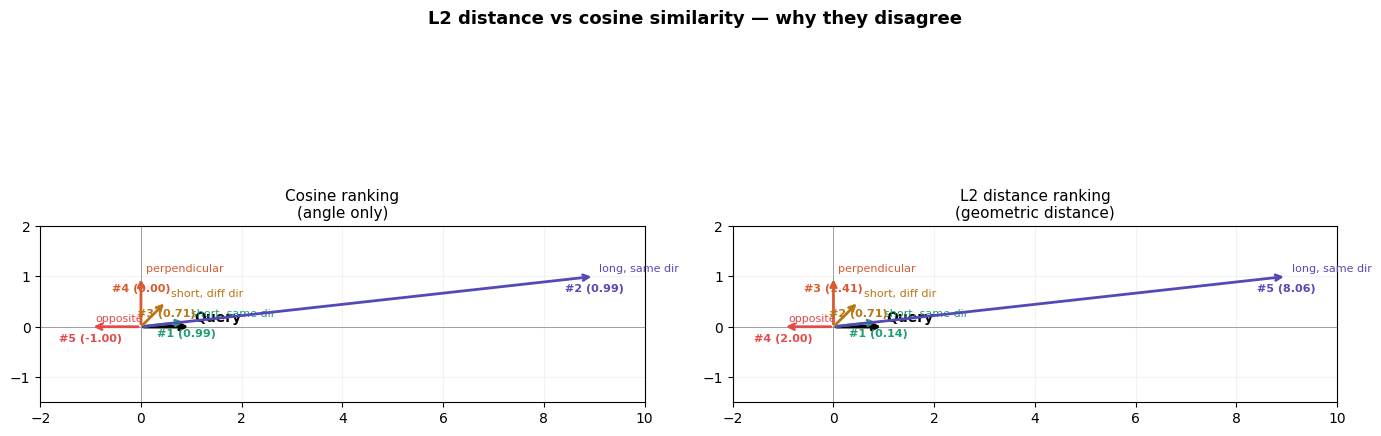

Saved: 05_l2_vs_cosine.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("L2 distance vs cosine similarity — why they disagree", fontsize=13, fontweight='bold')

colors_map = {
    "short, same dir": '#1D9E75', "long, same dir":  '#534AB7',
    "short, diff dir": '#BA7517', "perpendicular":   '#D85A30', "opposite": '#E24B4A',
}

for ax in axes:
    ax.set_xlim(-2, 10); ax.set_ylim(-1.5, 2)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.grid(True, alpha=0.15); ax.set_aspect('equal')
    ax.annotate('', xy=query, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5))
    ax.text(1.05, 0.1, 'Query', fontsize=10, fontweight='bold')
    for name, vec in docs_2d.items():
        ax.annotate('', xy=vec, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color=colors_map[name], lw=2))
        ax.text(vec[0]+0.1, vec[1]+0.1, name, fontsize=8, color=colors_map[name])

axes[0].set_title("Cosine ranking\n(angle only)", fontsize=11)
for rank, (score, name) in enumerate(cos_ranked, 1):
    vec = docs_2d[name]
    axes[0].text(vec[0], vec[1]-0.3, f"#{rank} ({score:.2f})",
                 fontsize=8, ha='center', color=colors_map[name], fontweight='bold')

axes[1].set_title("L2 distance ranking\n(geometric distance)", fontsize=11)
for rank, (dist, name) in enumerate(l2_ranked, 1):
    vec = docs_2d[name]
    axes[1].text(vec[0], vec[1]-0.3, f"#{rank} ({dist:.2f})",
                 fontsize=8, ha='center', color=colors_map[name], fontweight='bold')

plt.tight_layout()
plt.savefig('05_l2_vs_cosine.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_l2_vs_cosine.png")

---
## 9. Bonus: Build a Mini RAG Retriever <a id='9'></a>

Combine everything into a class that mirrors what LangChain / LlamaIndex do internally.

In [20]:
class MiniRAGRetriever:
    """
    Minimal retriever mirroring production RAG systems.
    Ingestion: embed docs + store.
    Retrieval: embed query -> cosine -> threshold -> top-k.
    """

    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model = SentenceTransformer(model_name)
        self.documents = []
        self.embeddings = None
        self.metadata = []

    def ingest(self, documents, metadata=None):
        """Embed and store documents."""
        self.documents = documents
        self.metadata = metadata or [{} for _ in documents]
        print(f"Embedding {len(documents)} documents...")
        self.embeddings = self.model.encode(documents, show_progress_bar=False)
        print(f"Done. Shape: {self.embeddings.shape}")
        return self

    def retrieve(self, query, top_k=5, threshold=0.0):
        """Retrieve top-k documents above threshold, ranked by score."""
        assert self.embeddings is not None, "Call ingest() first."
        q_vec = self.model.encode([query])
        scores = sklearn_cosine(q_vec, self.embeddings)[0]
        results = [
            {'document': self.documents[i], 'score': float(scores[i]),
             'metadata': self.metadata[i], 'idx': i}
            for i in range(len(self.documents))
            if scores[i] >= threshold
        ]
        results.sort(key=lambda x: x['score'], reverse=True)
        for rank, r in enumerate(results[:top_k], 1):
            r['rank'] = rank
        return results[:top_k]

    def format_context(self, results):
        """Format retrieved docs as LLM context string."""
        parts = []
        for r in results:
            source = r['metadata'].get('source', f'doc_{r["idx"]}')
            parts.append(f"[{r['rank']}] ({r['score']:.3f}) Source: {source}\n{r['document']}")
        return "\n\n".join(parts)

    def outlier_report(self):
        """Return documents sorted by avg corpus similarity (outliers first)."""
        matrix = sklearn_cosine(self.embeddings)
        n = len(self.documents)
        avgs = [(matrix[i].sum() - 1) / (n - 1) for i in range(n)]
        return sorted(
            [{'document': self.documents[i], 'avg_similarity': round(avgs[i], 4)} for i in range(n)],
            key=lambda x: x['avg_similarity']
        )


retriever = MiniRAGRetriever()
retriever.ingest(documents, metadata=[{'source': f'doc_{i:02d}.txt'} for i in range(len(documents))])

query = "puppy running in nature"
results = retriever.retrieve(query, top_k=3, threshold=0.25)
print(f"\nQuery: '{query}'")
print("=" * 60)
print("Context window (what would be passed to the LLM):")
print(retriever.format_context(results))

print("\nOutlier report:")
for r in retriever.outlier_report():
    print(f"  {r['avg_similarity']:.3f}  {r['document'][:55]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 9 documents...
Done. Shape: (9, 384)

Query: 'puppy running in nature'
Context window (what would be passed to the LLM):
[1] (0.581) Source: doc_01.txt
A puppy played in the green grass.

[2] (0.509) Source: doc_00.txt
The golden retriever ran across the park.

[3] (0.393) Source: doc_02.txt
Dogs love to fetch balls outdoors.

Outlier report:
  0.006  The stock market closed higher on Friday.
  0.078  Data science involves statistics and coding.
  0.079  A puppy played in the green grass.
  0.115  The labrador swam in the lake happily.
  0.124  Dogs love to fetch balls outdoors.
  0.129  The golden retriever ran across the park.
  0.132  Feature engineering improves model accuracy.
  0.157  Neural networks learn from large datasets.
  0.175  Machine learning models require clean data.


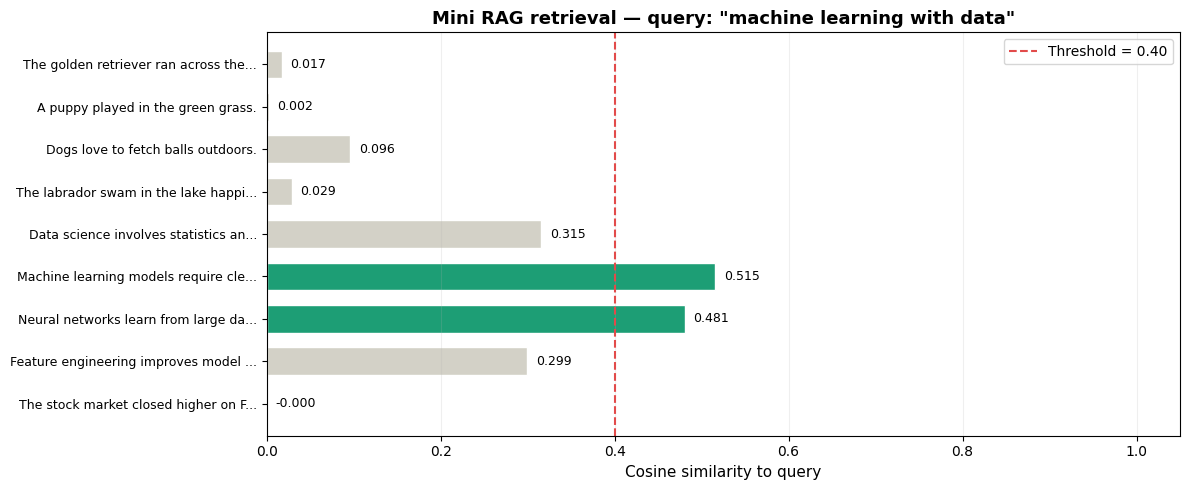

Saved: 06_mini_rag_retrieval.png


In [21]:
# Full pipeline summary chart
query = "machine learning with data"
q_vec = model.encode([query])
scores = sklearn_cosine(q_vec, embeddings)[0]

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#1D9E75' if s >= 0.40 else '#D3D1C7' for s in scores]
bars = ax.barh(range(len(documents)), scores, color=bar_colors, height=0.65, edgecolor='white')
ax.axvline(x=0.40, color='#E24B4A', linestyle='--', linewidth=1.5, label='Threshold = 0.40')
ax.set_yticks(range(len(documents)))
ax.set_yticklabels([d[:35] + '...' if len(d) > 35 else d for d in documents], fontsize=9)
ax.set_xlabel("Cosine similarity to query", fontsize=11)
ax.set_title(f'Mini RAG retrieval — query: "{query}"', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)

for bar, score in zip(bars, scores):
    ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
            f"{score:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('06_mini_rag_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_mini_rag_retrieval.png")

---
## 10. Challenge Tasks <a id='10'></a>

Complete these before moving to Stage 2 (PCA + real embedding models).

In [ ]:
# Challenge 1 — The normalized dot product trick
#
# sklearn internally normalizes vectors to unit length, then uses dot product.
# Prove this yourself:
#   1. Normalize every embedding to unit length (divide by its magnitude)
#   2. Compute the full matrix using @ (matrix multiply)
#   3. Show max diff vs sklearn_cosine(embeddings) is < 1e-10
#
# WHY THIS MATTERS: FAISS IndexFlatIP uses raw dot product.
# If you pre-normalize vectors before adding to FAISS, IP search == cosine search.
# Many production systems do this for GPU-accelerated cosine similarity.

# YOUR CODE HERE
# norms = ...
# normalized = ...
# matrix_via_dot = ...
# print("Max diff:", np.max(np.abs(matrix_via_dot - sklearn_cosine(embeddings))))

print("Challenge 1: implement the normalized dot product trick")

In [ ]:
# Challenge 2 — Threshold sensitivity analysis
#
# For query = "a dog running outside", sweep threshold from 0.0 to 1.0 in steps of 0.05.
# Plot: threshold (x-axis) vs number of documents returned (y-axis).
#
# Expected shape: a step function that drops as threshold rises.
# Engineering question to answer: where would you set the threshold for a
# medical insurance policy RAG system? Why?
# (hint: in healthcare, a bad retrieval is worse than no retrieval)

# YOUR CODE HERE

print("Challenge 2: threshold sensitivity curve")

In [ ]:
# Challenge 3 — Build your own 3-cluster corpus
#
# Create 12+ documents across 3 clearly distinct topics.
# Run the full heatmap on them.
# A correct implementation shows a clear block-diagonal pattern:
#   3 warm blocks along the diagonal (intra-cluster similarity)
#   cold off-diagonal regions (inter-cluster similarity)
#
# If clusters bleed into each other, your topics are not distinct enough.

my_documents = [
    # Topic 1: (add 4+ sentences)
    # Topic 2: (add 4+ sentences)
    # Topic 3: (add 4+ sentences)
]

# my_embeddings = model.encode(my_documents)
# my_matrix = sklearn_cosine(my_embeddings)
# ... plot heatmap

print("Challenge 3: 3-cluster corpus + heatmap verification")

In [ ]:
# Challenge 4 (Hard) — Build an eval harness
#
# Create 5 (query, expected_top_doc_idx) pairs from the existing corpus.
# For each:
#   1. Run retrieve() to get the top-1 result
#   2. Check if idx matches expected_top_doc_idx
#   3. Record hit (1) or miss (0)
# Report hit@1 accuracy.
#
# This is exactly what RAGAS and other RAG eval frameworks do at scale.
# Building it yourself teaches you what "retrieval quality" actually means.

eval_pairs = [
    ("golden retriever fetch", 0),  # expected: documents[0]
    # ("your query here", expected_doc_index),
    # add 4 more pairs
]

# YOUR CODE HERE
# hits = 0
# for query, expected_idx in eval_pairs:
#     results = retrieve(query, documents, embeddings, model, top_k=1)
#     if results and results[0]['idx'] == expected_idx:
#         hits += 1
# print(f"hit@1 accuracy: {hits}/{len(eval_pairs)} = {hits/len(eval_pairs):.0%}")

print("Challenge 4: hit@1 eval harness")

---
## Summary

| Concept | What you built | Why it matters in RAG |
|---|---|---|
| Dot product | From scratch (numpy only) | Foundation of all similarity math |
| Magnitude | sqrt(sum of squares) | Required for cosine normalization |
| Cosine similarity | Scratch + verified vs sklearn | Core retrieval metric |
| Similarity matrix | Full N×N computation | Reveals corpus structure |
| Heatmap | seaborn visualization | Debug clustering and redundancy |
| Outlier detection | Z-score on avg similarity | Catch bad chunks at ingestion time |
| Threshold retrieval | score >= threshold filter | Prefer silence over bad answers |
| L2 vs cosine | Side-by-side visual proof | Why cosine beats L2 for text length |
| MiniRAGRetriever | Full class: ingest + retrieve | Production-ready pattern |

**Next:** Stage 2 — embed 50 real sentences, reduce to 2D with PCA, and plot the semantic space.
